In [73]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv("insurance - insurance.csv")

print("First 10 Rows of Dataset:\n")
print(df.head(10))


First 10 Rows of Dataset:

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14


In [75]:
print("\nShape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape of Dataset:
(1338, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Statistical Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75% 

In [76]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())



Missing Values in Each Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [78]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['str']).columns

print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


Numerical Columns:
['age', 'bmi', 'children', 'expenses']

Categorical Columns:
['sex', 'smoker', 'region']


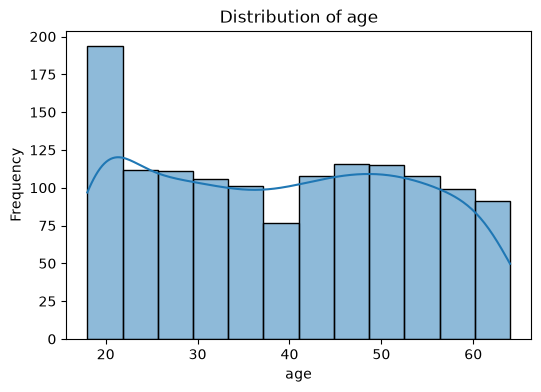

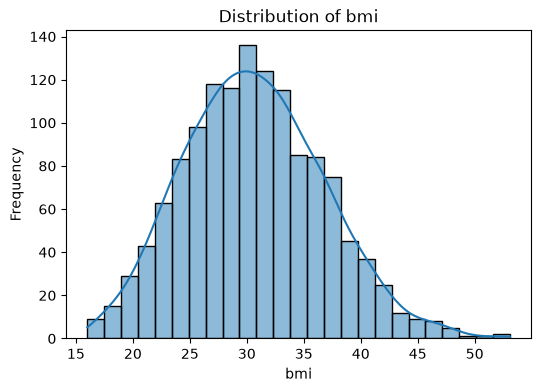

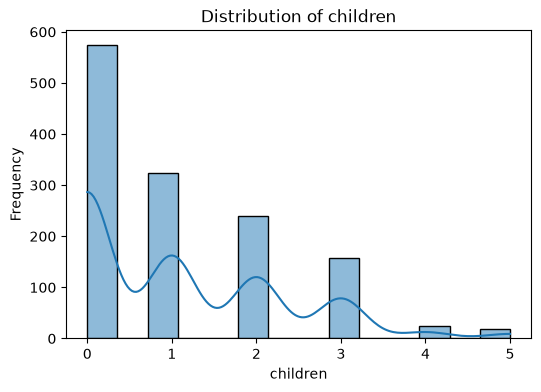

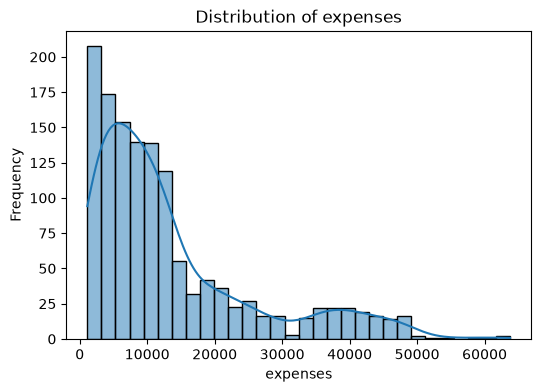

In [88]:

num_cols = ['age', 'bmi', 'children', 'expenses']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


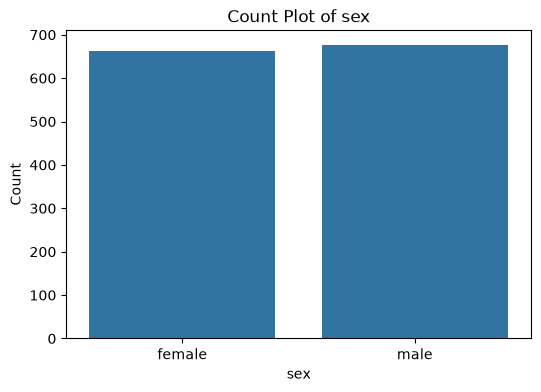

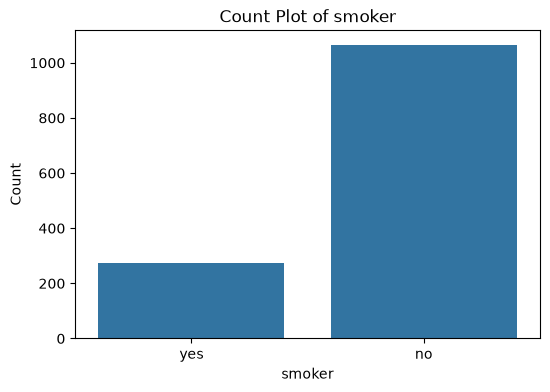

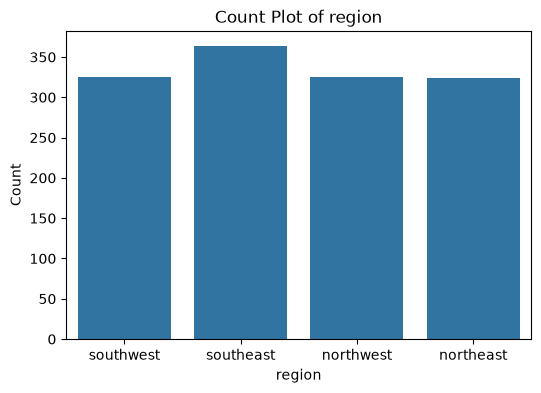

In [85]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

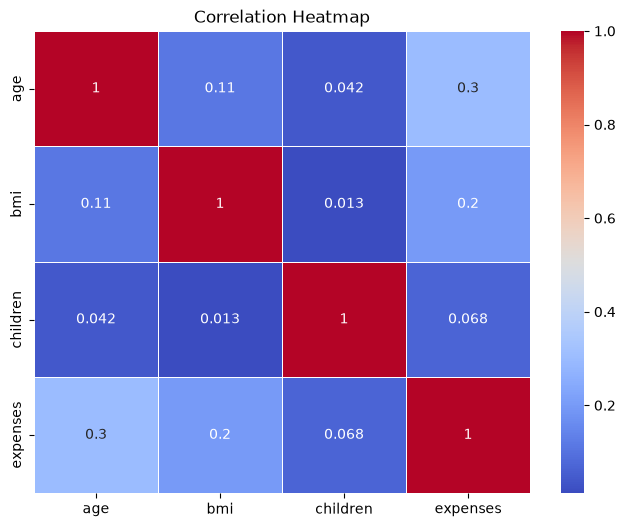

In [86]:
plt.figure(figsize=(8,6))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [89]:
print("\nAverage Insurance Charges:")
print(df['expenses'].mean())

print("\nMaximum Insurance Charges:")
print(df['expenses'].max())

print("\nMinimum Insurance Charges:")
print(df['expenses'].min())

print("\nAverage Charges by Smoker Status:")
print(df.groupby('smoker')['expenses'].mean())


Average Insurance Charges:
13270.422414050823

Maximum Insurance Charges:
63770.43

Minimum Insurance Charges:
1121.87

Average Charges by Smoker Status:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


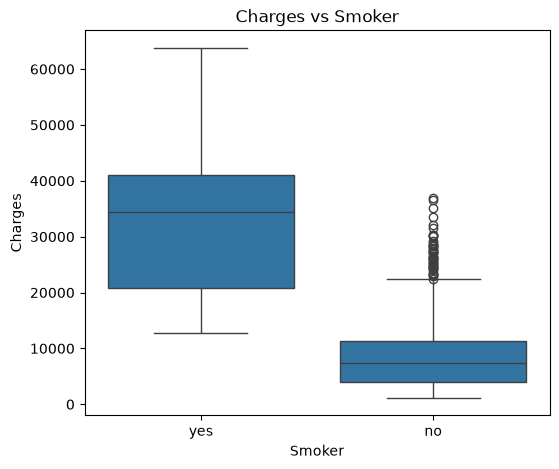

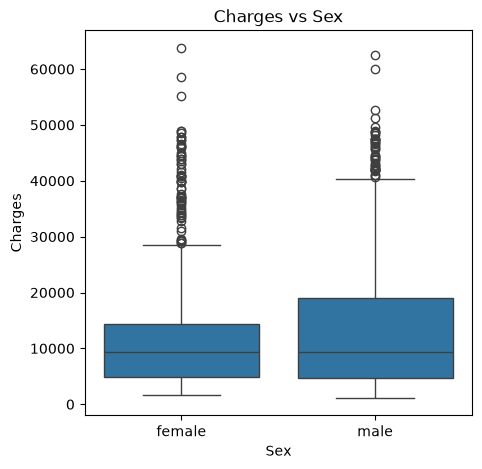

In [99]:
# Charges vs Smoker
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Charges vs Smoker")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

# Charges vs Sex
plt.figure(figsize=(5,5))
sns.boxplot(x='sex', y='expenses', data=df)
plt.title("Charges vs Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.show()


In [101]:
print("\n========== ANALYSIS SUMMARY ==========")

print("\n1. Average Age:")
print(df['age'].mean())

print("\nAverage BMI:")
print(df['bmi'].mean())

print("\n2. Average Charges by Smoking Status:")
print(df.groupby('smoker')['expenses'].mean())

print("\n3. Region with Highest Number of Customers:")
print(df['region'].value_counts())

highest_region = df['region'].value_counts().idxmax()
print("\nHighest Customer Region:", highest_region)

print("""
4. Interesting Observations:

• Smokers pay significantly higher insurance charges than non-smokers.

• Charges have a positive relationship with BMI and age.

• Most customers belong to the region printed above.

• Age and BMI are approximately normally distributed.

• The number of male and female customers is nearly equal.

• The distribution of charges is right-skewed with some high-cost outliers.
""")


========== ANALYSIS SUMMARY ==========

1. Average Age:
39.20702541106129

Average BMI:
30.66547085201794

2. Average Charges by Smoking Status:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64

3. Region with Highest Number of Customers:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Highest Customer Region: southeast

4. Interesting Observations:

• Smokers pay significantly higher insurance charges than non-smokers.

• Charges have a positive relationship with BMI and age.

• Most customers belong to the region printed above.

• Age and BMI are approximately normally distributed.

• The number of male and female customers is nearly equal.

• The distribution of charges is right-skewed with some high-cost outliers.

